In [1]:
# Import  libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

# Set style for plots
plt.style.use('seaborn-v0_8')
sns.set_palette("viridis")

In [2]:
# Load the airpoll dataset
df = pd.read_excel('airpoll spreadsheet.xlsx')


In [3]:
# Explore the dataset structure
print("Dataset Information:")
print("=" * 50)
print(f"Shape: {df.shape} (rows, columns)")
print(f"\nColumn names: {list(df.columns)}")
print(f"\nData types:\n{df.dtypes}")
print(f"\nMissing values:\n{df.isnull().sum()}")

Dataset Information:
Shape: (3347, 5) (rows, columns)

Column names: ['SO2', 'NO2', 'O3', 'PM2.5', 'PM10']

Data types:
SO2      float64
NO2      float64
O3       float64
PM2.5    float64
PM10     float64
dtype: object

Missing values:
SO2      0
NO2      0
O3       0
PM2.5    0
PM10     0
dtype: int64


In [4]:
# Handling missing values if any
if df.isnull().sum().sum() > 0:
    print("Missing values found. Handling them...")
    # Display missing values before handling
    print("Missing values before handling:")
    print(df.isnull().sum())

    # Filling missing values with mean (appropriate for numerical data)
    df.fillna(df.mean(), inplace=True)

    print("\nMissing values after handling:")
    print(df.isnull().sum())
else:
    print("No missing values found in the dataset.")

No missing values found in the dataset.


In [5]:
# Descriptive statistical analysis
print("Descriptive Statistics:")
print("=" * 50)
print(df.describe())

# Additional statistics
print("\nAdditional Statistics:")
print("=" * 30)
for col in df.columns:
    if df[col].dtype in ['int64', 'float64']:
        print(f"{col}:")
        print(f"  Range: {df[col].min():.2f} - {df[col].max():.2f}")
        print(f"  Variance: {df[col].var():.2f}")
        print(f"  Skewness: {df[col].skew():.2f}")
        print(f"  Kurtosis: {df[col].kurtosis():.2f}")
        print()

Descriptive Statistics:
               SO2          NO2           O3        PM2.5         PM10
count  3347.000000  3347.000000  3347.000000  3347.000000  3347.000000
mean     15.457743    30.233894    49.046178    30.840341    53.068965
std       7.958836     9.840362    13.678701    10.881794    19.495417
min       2.440214     5.313647    14.307370     7.247189    12.460333
25%       9.822467    23.342326    38.955383    23.265236    39.293278
50%      13.668863    28.622035    47.986737    29.131225    49.776500
75%      19.211052    35.268649    57.857050    36.256992    63.601911
max      63.565143    80.808551   103.912130    80.611000   131.746833

Additional Statistics:
SO2:
  Range: 2.44 - 63.57
  Variance: 63.34
  Skewness: 1.48
  Kurtosis: 3.38

NO2:
  Range: 5.31 - 80.81
  Variance: 96.83
  Skewness: 0.97
  Kurtosis: 1.38

O3:
  Range: 14.31 - 103.91
  Variance: 187.11
  Skewness: 0.37
  Kurtosis: -0.18

PM2.5:
  Range: 7.25 - 80.61
  Variance: 118.41
  Skewness: 1.04
  Kur

Correlation Matrix:


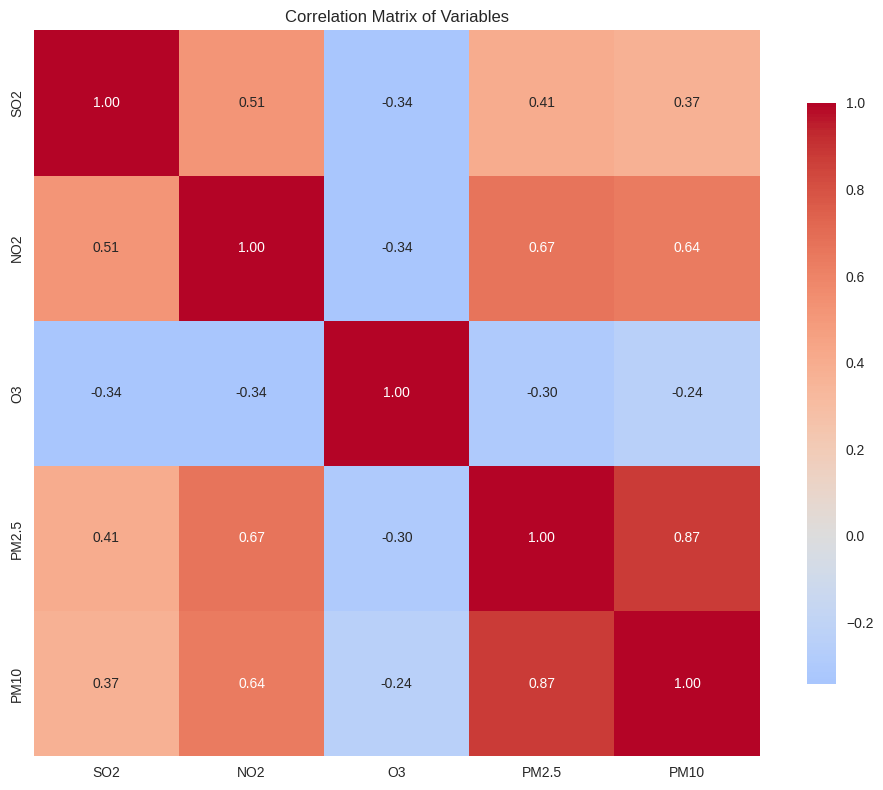


Strong Correlations (|r| > 0.7):
PM2.5 - PM10: 0.875


In [6]:
# Show correlation between variables
print("Correlation Matrix:")
print("=" * 50)

# Calculate correlation matrix
correlation_matrix = df.corr()

# Display correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0,
            square=True, fmt='.2f', cbar_kws={'shrink': 0.8})
plt.title('Correlation Matrix of Variables')
plt.tight_layout()
plt.show()

# Print strong correlations (absolute value > 0.7)
print("\nStrong Correlations (|r| > 0.7):")
print("=" * 40)
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        corr_value = correlation_matrix.iloc[i, j]
        if abs(corr_value) > 0.7:
            print(f"{correlation_matrix.columns[i]} - {correlation_matrix.columns[j]}: {corr_value:.3f}")

Distribution of Variables:


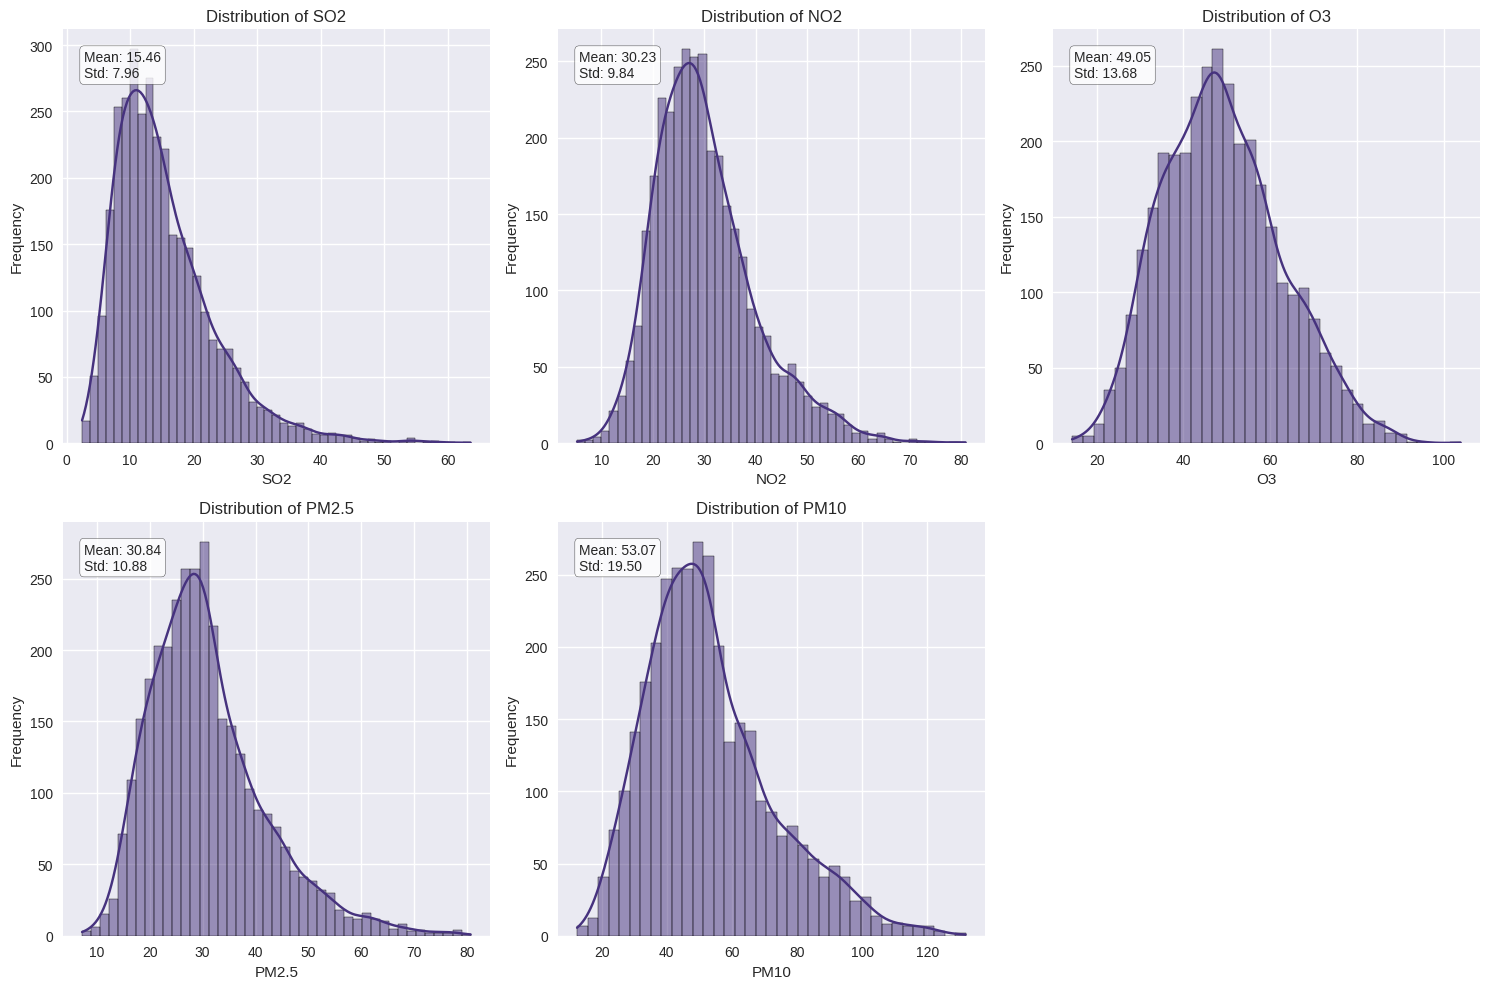

In [7]:
# Display distribution of each pollutant/variable
print("Distribution of Variables:")
print("=" * 50)

# Determine grid size for subplots
n_cols = 3
n_rows = (len(df.columns) + n_cols - 1) // n_cols

# Create subplots
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5*n_rows))
axes = axes.flatten()

for i, column in enumerate(df.columns):
    if df[column].dtype in ['int64', 'float64']:
        # Histogram with KDE
        sns.histplot(df[column], kde=True, ax=axes[i])
        axes[i].set_title(f'Distribution of {column}')
        axes[i].set_xlabel(column)
        axes[i].set_ylabel('Frequency')

        # Add statistics to the plot
        stats_text = f'Mean: {df[column].mean():.2f}\nStd: {df[column].std():.2f}'
        axes[i].text(0.05, 0.95, stats_text, transform=axes[i].transAxes,
                    verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# Hide empty subplots
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

In [8]:
# Data standardization for k-means
print("Standardizing data for k-means clustering...")
from sklearn.preprocessing import StandardScaler

# Standardize the data (k-means is sensitive to scale)
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)

# Create DataFrame with scaled data
scaled_df = pd.DataFrame(scaled_data, columns=df.columns)
print("Data standardization completed!")
print("\nFirst 5 rows of scaled data:")
print(scaled_df.head().round(3))

Standardizing data for k-means clustering...
Data standardization completed!

First 5 rows of scaled data:
     SO2    NO2     O3  PM2.5   PM10
0 -0.426 -0.409  0.090 -0.065 -0.178
1 -0.691 -0.388  0.123  0.790  0.537
2 -0.304 -0.209  0.776 -0.073 -0.075
3 -0.169  0.020 -0.293  0.451  0.350
4  0.127 -0.433 -0.197 -0.739 -0.671


Determining optimal number of clusters using Elbow Method...


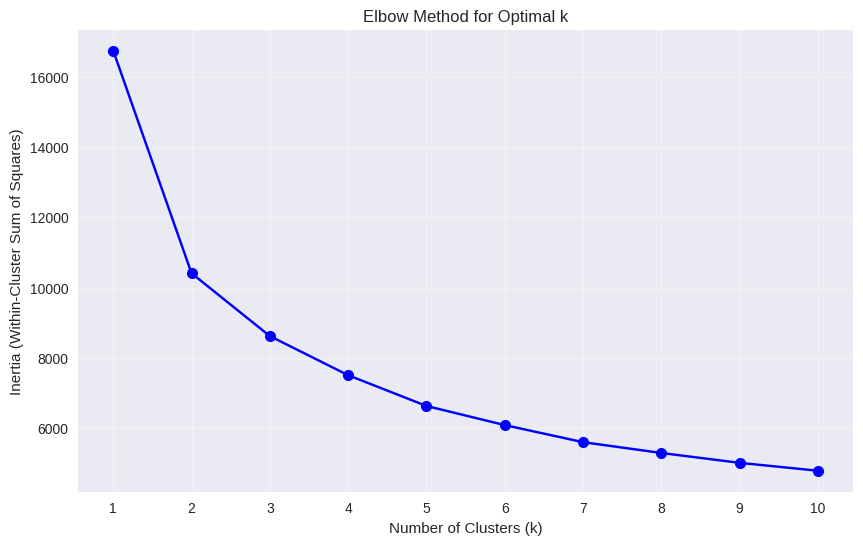

Inertia differences: ['-6326.77', '-1785.44', '-1111.86', '-875.01', '-543.26', '-485.64', '-307.73', '-280.06', '-224.45']


In [9]:
# Determine optimal number of clusters using Elbow Method
print("Determining optimal number of clusters using Elbow Method...")
from sklearn.cluster import KMeans

# Calculate inertia for different k values
inertia = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(scaled_df)
    inertia.append(kmeans.inertia_)

# Plot elbow curve
plt.figure(figsize=(10, 6))
plt.plot(k_range, inertia, 'bo-', markersize=8)
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (Within-Cluster Sum of Squares)')
plt.title('Elbow Method for Optimal k')
plt.xticks(k_range)
plt.grid(True, alpha=0.3)
plt.show()

# Calculate the change in inertia to help identify the elbow point
inertia_diff = np.diff(inertia)
inertia_ratio = inertia_diff[:-1] / inertia_diff[1:]
print("Inertia differences:", [f"{x:.2f}" for x in inertia_diff])

Calculating Silhouette Scores for different k values...
k = 2: Silhouette Score = 0.3705
k = 3: Silhouette Score = 0.2314
k = 4: Silhouette Score = 0.2043
k = 5: Silhouette Score = 0.2143
k = 6: Silhouette Score = 0.2012
k = 7: Silhouette Score = 0.2105
k = 8: Silhouette Score = 0.1863
k = 9: Silhouette Score = 0.1893
k = 10: Silhouette Score = 0.1822


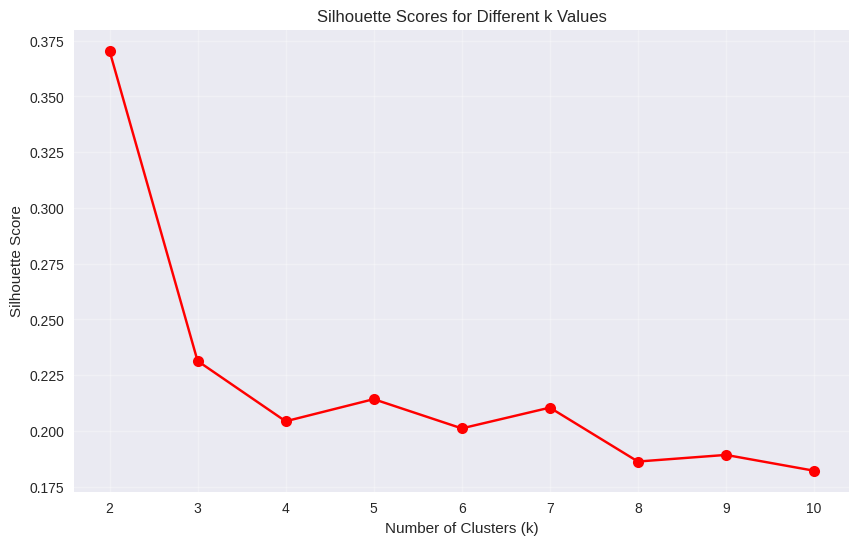


Based on analysis, optimal number of clusters: 2


In [10]:
# Use Silhouette Score to validate optimal k
print("Calculating Silhouette Scores for different k values...")
from sklearn.metrics import silhouette_score

silhouette_scores = []
k_range_silhouette = range(2, 11)  # Silhouette requires at least 2 clusters

for k in k_range_silhouette:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(scaled_df)
    silhouette_avg = silhouette_score(scaled_df, cluster_labels)
    silhouette_scores.append(silhouette_avg)
    print(f"k = {k}: Silhouette Score = {silhouette_avg:.4f}")

# Plot silhouette scores
plt.figure(figsize=(10, 6))
plt.plot(k_range_silhouette, silhouette_scores, 'ro-', markersize=8)
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Scores for Different k Values')
plt.xticks(k_range_silhouette)
plt.grid(True, alpha=0.3)
plt.show()

# Determine optimal k
optimal_k = np.argmax(silhouette_scores) + 2  # +2 because we started from k=2
print(f"\nBased on analysis, optimal number of clusters: {optimal_k}")